In [1]:
# Install if needed
!pip install -q albumentations

# Standard
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt

print("Setup done ✅")


Setup done ✅


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Adjust folder name to match your input dataset in Kaggle
meta = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print(meta.head())
print(meta['dx'].value_counts())


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [3]:
def get_image_path(image_id):
    path1 = f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/{image_id}.jpg"
    path2 = f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/{image_id}.jpg"
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None  # not found


In [4]:
meta['image_path'] = meta['image_id'].apply(get_image_path)

missing = meta['image_path'].isnull().sum()
print(f"Missing images: {missing}")


Missing images: 0


In [5]:
le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])
print(dict(zip(le.classes_, range(len(le.classes_)))))


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [6]:
train_df, val_df = train_test_split(
    meta,
    test_size=0.2,
    stratify=meta['label'],
    random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}")


Train: 8012, Val: 2003


In [7]:
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)


In [8]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        image = np.array(Image.open(img_path).convert('RGB'))
        label = self.df.loc[idx, 'label']

        if self.transform:
            image = self.transform(image=image)['image']

        return image, label


In [9]:
train_transforms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])


In [10]:
train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Batches in train loader: {len(train_loader)}")


Batches in train loader: 251


In [11]:
import torch
print("Is CUDA available?", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Is CUDA available? True
Device: Tesla T4


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features, len(le.classes_))
model = model.to(device)

import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


In [13]:
print(train_df.columns)
print(val_df.columns)


Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='object')
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='object')


In [14]:
train_df['image_path'] = train_df['image_id'].apply(get_image_path)
val_df['image_path'] = val_df['image_id'].apply(get_image_path)

print(train_df[['image_id', 'image_path']].head())


          image_id                                         image_path
8050  ISIC_0033319  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4898  ISIC_0030823  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
9695  ISIC_0028730  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4090  ISIC_0027299  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
8625  ISIC_0032444  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...


In [15]:
epochs = 40

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()

    train_acc = correct / len(train_dataset)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}")

    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()

    val_acc = correct / len(val_dataset)
    print(f"Validation Acc: {val_acc:.4f}")


Epoch 1, Loss: 167.5106, Train Acc: 0.7651
Validation Acc: 0.8298
Epoch 2, Loss: 104.9646, Train Acc: 0.8492
Validation Acc: 0.8382
Epoch 3, Loss: 71.0756, Train Acc: 0.8975
Validation Acc: 0.8417
Epoch 4, Loss: 52.0198, Train Acc: 0.9270
Validation Acc: 0.8382
Epoch 5, Loss: 35.4482, Train Acc: 0.9512
Validation Acc: 0.8522
Epoch 6, Loss: 30.0909, Train Acc: 0.9612
Validation Acc: 0.8472
Epoch 7, Loss: 20.1081, Train Acc: 0.9749
Validation Acc: 0.8642
Epoch 8, Loss: 17.2561, Train Acc: 0.9788
Validation Acc: 0.8522
Epoch 9, Loss: 16.9061, Train Acc: 0.9788
Validation Acc: 0.8527
Epoch 10, Loss: 15.6420, Train Acc: 0.9773
Validation Acc: 0.8422
Epoch 11, Loss: 14.7009, Train Acc: 0.9820
Validation Acc: 0.8422
Epoch 12, Loss: 14.7371, Train Acc: 0.9795
Validation Acc: 0.8557
Epoch 13, Loss: 11.4327, Train Acc: 0.9840
Validation Acc: 0.8572
Epoch 14, Loss: 9.6951, Train Acc: 0.9883
Validation Acc: 0.8632
Epoch 15, Loss: 11.2119, Train Acc: 0.9846
Validation Acc: 0.8677
Epoch 16, Loss: 9.

In [16]:
torch.save(model.state_dict(), 'resnet18_ham10000.pth')

import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le.classes_, f)


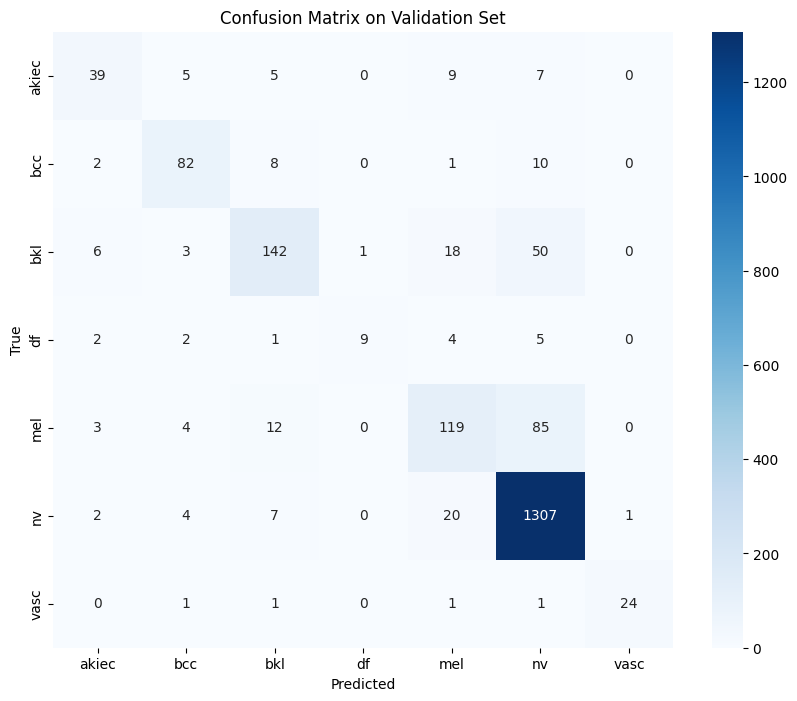

In [17]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure model is on the same device as validation data
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# If you want pretty labels:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot with seaborn for nicer colors
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Set')
plt.show()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Predicted class: akiec


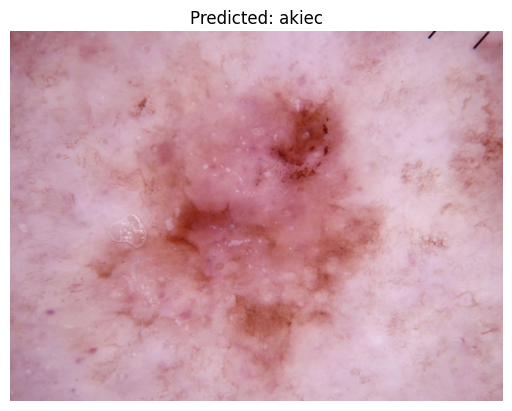

In [18]:
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import pickle

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---------------------------
# 1) Load your model architecture
# ---------------------------
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(le.classes_))  # 7 classes for HAM10000

# Load weights
model.load_state_dict(torch.load('/kaggle/working/resnet18_ham10000.pth'))
model.eval()
model = model.to(device)

# ---------------------------
# 2) Load your label encoder
# ---------------------------
# If you saved it, load it. Otherwise, use the same le you trained:
# with open('label_encoder.pkl', 'rb') as f:
#     classes = pickle.load(f)
# Or just use:
classes = le.classes_

# ---------------------------
# 3) Define the test transform
# (same as your val transforms!)
# ---------------------------
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

# ---------------------------
# 4) Load and preprocess a test image
# ---------------------------
img_path = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024372.jpg"  # example
image = Image.open(img_path).convert('RGB')

# Albumentations needs numpy array
image_np = np.array(image)
augmented = test_transform(image=image_np)
image_tensor = augmented['image'].unsqueeze(0).to(device)  # add batch dimension

# ---------------------------
# 5) Run the prediction
# ---------------------------
with torch.no_grad():
    outputs = model(image_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_label = classes[predicted.item()]

print(f"Predicted class: {predicted_label}")

# ---------------------------
# 6) Show the image
# ---------------------------
plt.imshow(image)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()
